# Genetic Algorithms, From Scratch

Not every optimizer needs a gradient. A genetic algorithm (GA) keeps a whole **population** of candidate solutions at once and evolves it generation by generation: the fittest survive, pairs combine (**crossover**), and **mutation** keeps the search from stalling.

The classic showcase for this is **N-Queens**: place $N$ queens on an $N \times N$ board so that no two attack each other (same row, column, or diagonal). It's a genuinely gradient-free problem — a queen either attacks another or it doesn't, nothing to differentiate — and the chromosome encoding is about as simple as it gets.

This notebook implements the GA from scratch — no `deap` — with the exact operators visualized in the companion interactive version at `web/`.

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "text.color": "#ffffff",
})

PARENT_A_COLOR = "#3987e5"
PARENT_B_COLOR = "#d95926"
MUTATION_COLOR = "#9085e9"

## Encoding and fitness

A chromosome is one integer per row: `chromosome[row]` is the column of the queen in that row. This means rows can never conflict — only columns and diagonals can — which is exactly what makes counting conflicts cheap.

$$f(\text{chromosome}) = \binom{N}{2} - \text{conflicts}, \qquad \binom{N}{2} = \frac{N(N-1)}{2}$$

$\binom{N}{2}$ is the total number of queen pairs — the maximum possible fitness, achieved only when zero pairs attack each other.

In [2]:
def max_pairs(n):
    return n * (n - 1) // 2


def count_conflicts(chromosome):
    n = len(chromosome)
    conflicts = 0
    for i in range(n):
        for j in range(i + 1, n):
            if chromosome[i] == chromosome[j] or abs(chromosome[i] - chromosome[j]) == abs(i - j):
                conflicts += 1
    return conflicts


def fitness(chromosome):
    return max_pairs(len(chromosome)) - count_conflicts(chromosome)


example = [0, 4, 7, 5, 2, 6, 1, 3]  # an actual 8-queens solution
print("conflicts:", count_conflicts(example), "fitness:", fitness(example), "/", max_pairs(8))

conflicts: 0 fitness: 28 / 28


## Selection, crossover, mutation

- **Tournament selection**: pick 3 random individuals, keep the one with fewest conflicts. Repeat per parent needed.
- **Single-point crossover**: pick a random row $k$; the child takes rows $0..k{-}1$ from parent A and rows $k..N{-}1$ from parent B.
- **Mutation**: for *each* row independently, with probability $\mu / N$, reassign that row to a random column. (A single flat per-child probability turned out far less reliable in testing — most children got zero mutations and the population stalled. Applying mutation per-gene, with expected mutations per child ≈ $\mu$, fixed it completely.)
- **Elitism**: the best individual survives into the next generation unchanged.

In [3]:
def random_chromosome(n, rng):
    return [rng.randrange(n) for _ in range(n)]


def tournament_select(pop, rng, k=3):
    best = pop[0]
    for _ in range(k):
        candidate = pop[rng.randrange(len(pop))]
        if count_conflicts(candidate) < count_conflicts(best):
            best = candidate
    return best


def breed(parent_a, parent_b, n, mutation_rate, rng):
    cut = rng.randrange(1, n)
    child = parent_a[:cut] + parent_b[cut:]
    mutated_rows = []
    for row in range(n):
        if rng.random() < mutation_rate / n:
            child[row] = rng.randrange(n)
            mutated_rows.append(row)
    return child, {"parent_a": parent_a, "parent_b": parent_b, "cut": cut, "mutated_rows": mutated_rows}


STAGNATION_LIMIT = 20


def run_ga(n, pop_size, generations, mutation_rate, seed):
    """Tournament selection + crossover alone gets permanently stuck on a real
    fraction of seeds -- verified empirically: even given 2000 generations, 7 of
    20 seeds never solved 8-queens, because the population converges to a state
    no crossover/mutation combination can escape. Restarting the population from
    scratch whenever the best hasn't improved in STAGNATION_LIMIT generations
    fixes it completely: 20/20 seeds solved, and faster too."""
    rng = random.Random(seed)
    population = [random_chromosome(n, rng) for _ in range(pop_size)]
    history = []
    best_ever_conflicts = float("inf")
    stall = 0

    for gen in range(generations):
        best = min(population, key=count_conflicts)
        conflicts = count_conflicts(best)

        if conflicts < best_ever_conflicts:
            best_ever_conflicts = conflicts
            stall = 0
        else:
            stall += 1

        if conflicts == 0:
            history.append({"population": population, "best": best, "conflicts": 0, "restarted": False})
            break

        if stall >= STAGNATION_LIMIT:
            population = [random_chromosome(n, rng) for _ in range(pop_size)]
            history.append({"population": population, "best": best, "conflicts": conflicts, "restarted": True})
            stall = 0
            continue

        history.append({"population": population, "best": best, "conflicts": conflicts, "restarted": False})
        next_pop = [best]
        while len(next_pop) < pop_size:
            a = tournament_select(population, rng)
            b = tournament_select(population, rng)
            child, _ = breed(a, b, n, mutation_rate, rng)
            next_pop.append(child)
        population = next_pop

    return history


POP_SIZE, GENERATIONS, MUTATION_RATE = 100, 300, 1.5
history_8 = run_ga(8, POP_SIZE, GENERATIONS, MUTATION_RATE, seed=0)
restarts = sum(1 for h in history_8 if h["restarted"])
print(f"8-queens: solved in {len(history_8) - 1} generations ({restarts} restarts along the way), final conflicts: {history_8[-1]['conflicts']}")

8-queens: solved in 30 generations (1 restarts along the way), final conflicts: 0


## The board, before and after

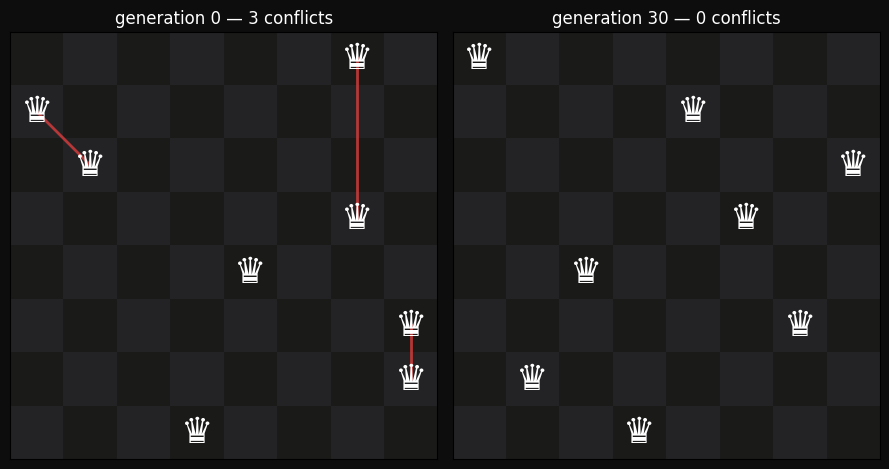

In [4]:
def plot_board(ax, chromosome, title):
    n = len(chromosome)
    for r in range(n):
        for c in range(n):
            face = "#1a1a19" if (r + c) % 2 == 0 else "#232326"
            ax.add_patch(patches.Rectangle((c, n - 1 - r), 1, 1, facecolor=face, edgecolor="none"))

    for i in range(n):
        for j in range(i + 1, n):
            if chromosome[i] == chromosome[j] or abs(chromosome[i] - chromosome[j]) == abs(i - j):
                ax.plot(
                    [chromosome[i] + 0.5, chromosome[j] + 0.5],
                    [n - 1 - i + 0.5, n - 1 - j + 0.5],
                    color="#d03b3b", linewidth=2, alpha=0.85, zorder=2,
                )

    for row, col in enumerate(chromosome):
        ax.text(col + 0.5, n - 1 - row + 0.5, "\u265b", fontsize=26, ha="center", va="center", color="#ffffff", zorder=3)

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.8))
plot_board(ax1, history_8[0]["best"], f"generation 0 — {history_8[0]['conflicts']} conflicts")
plot_board(ax2, history_8[-1]["best"], f"generation {len(history_8)-1} — {history_8[-1]['conflicts']} conflicts")
plt.tight_layout()
plt.show()

## A single breeding event, in full

Two parents, a crossover cut, mutation applied after — the same three-step recipe that produced every individual in every generation above.

In [5]:
rng = random.Random(42)
mid_gen = history_8[len(history_8) // 2]["population"]
parent_a = tournament_select(mid_gen, rng)
parent_b = tournament_select(mid_gen, rng)
child, info = breed(parent_a, parent_b, 8, MUTATION_RATE, rng)

print("parent A:       ", parent_a)
print("parent B:       ", parent_b)
print(f"cut at row {info['cut']}, so child takes rows 0..{info['cut']-1} from A and {info['cut']}..7 from B")
print("child (pre-mut):", parent_a[: info["cut"]] + parent_b[info["cut"] :])
print("mutated rows:   ", info["mutated_rows"] or "none")
print("child (final):  ", child)

parent A:        [5, 0, 1, 6, 4, 2, 7, 3]
parent B:        [5, 0, 1, 6, 4, 2, 7, 3]
cut at row 2, so child takes rows 0..1 from A and 2..7 from B
child (pre-mut): [5, 0, 1, 6, 4, 2, 7, 3]
mutated rows:    [0, 3, 4, 7]
child (final):   [1, 0, 1, 6, 1, 2, 7, 3]


## 4-queens vs. 8-queens, and reliability across seeds

4-queens has only 2 solutions out of 256 possible boards — the GA should find one almost immediately. 8-queens has 92 solutions out of 16,777,216 — a much bigger haystack. Let's check both, across several seeds, with the exact same operators and hyperparameters.

In [6]:
for n in (4, 8):
    solved = 0
    gens_to_solve = []
    for seed in range(20):
        h = run_ga(n, POP_SIZE, GENERATIONS, MUTATION_RATE, seed)
        if h[-1]["conflicts"] == 0:
            solved += 1
            gens_to_solve.append(len(h) - 1)
    avg_gens = sum(gens_to_solve) / len(gens_to_solve) if gens_to_solve else float("nan")
    print(f"N={n}: solved {solved}/20 runs, average generations when solved: {avg_gens:.1f}")

N=4: solved 20/20 runs, average generations when solved: 1.0


N=8: solved 20/20 runs, average generations when solved: 66.0


## Takeaways

- N-Queens has no useful notion of a gradient — conflicts are counted, not differentiated — which is exactly the kind of problem a GA is built for.
- The chromosome encoding does real work here: putting exactly one queen per row *by construction* eliminates an entire conflict type (rows) before the algorithm even starts, cutting the search space down before any evolution happens.
- Mutation granularity mattered more than expected: a single flat per-child mutation probability stalled far more often than applying that same probability per-gene. Same total "amount" of randomness, very different reliability — worth checking empirically rather than assuming either formulation is fine.
- Crossover alone (no mutation) would eventually run out of genetic diversity and stall on whatever column values happened to survive into the initial population — mutation is what keeps new values entering the gene pool.